# Topic classification for German news articles - Support Vector Machine

# 1. Data import

In [1]:
import pandas as pd
import csv

In [2]:
# Import dataset and organize df
art_df = pd.read_csv('articles.csv', encoding='utf-8', delimiter=';', quotechar='\'', quoting=csv.QUOTE_MINIMAL)

# Import test data
# test_df = pd.read_csv('test.csv', encoding='utf-8', delimiter=';', quotechar='\'', quoting=csv.QUOTE_MINIMAL)

# Reset col names to first row
art_df=art_df.T.reset_index().T.reset_index(drop=True)

# Add new col names to train_df
art_df = art_df.rename(columns={0: 'cat', 1: 'text'})

# Set option to display more content in cells
pd.set_option('display.max_colwidth', 500)

art_df#.head(3)

,cat,text
0,Etat,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche..."
1,Etat,"App sei nicht so angenommen worden wie geplant. Wegen zu geringer Nutzung schaltet Spiegel Online nach zwei Jahren die Fußball-App aus, die App sei nicht so genutzt worden, wie man sich das vorgestellt habe. Dafür soll der Live-Fußball-Bereich in der News-App ausgebaut werden."
2,Etat,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L..."
3,Etat,"Mitarbeiter überreichten Eigentümervertretern Petition gegen Personalabbau. Wien – Mehrere hundert APA-Mitarbeiter haben laut dem Betriebsrat eine Resolution unterschrieben, die am Mittwoch den Eigentümervertretern übergeben wurde. Inhalt ist ein deutlicher Protest gegen den geplanten Personalabbau (DER STANDARD berichtete) und für eine Gleichstellung der Mitarbeiter von APA-Tochterunternehmen bei automatischen Gehaltsanpassungen. Ich lehne erneute Personalkürzungen oder gar Kündigungen, wie..."
4,Etat,"Service: Jobwechsel in der Kommunikationsbranche im Überblick. Hier liefert derStandard.at/Etat Jobwechsel in der Kommunikationsbranche im Überblick. Grob sortiert nach Kalenderwochen, in denen die Infos einlangten. Quellen: Presse- und eigene Infos, andere Branchendienste wie Horizont.at und medianet.at. Wenn Sie Infos für uns haben, bitte ein Mail an etat@derstandard.at schicken. Woche 15 / 2017 Woche 14 / 2017 Woche 13 / 2017 Woche 12 / 2017 Woche 9 / 2017 Woche 8 / 2017 Woche 7 / 2017 Sp..."
...,...,...
10268,Wissenschaft,"Die Fundstelle in Südengland ist Unesco-Weltkulturerbe, neolithische Ikone und das archäologische Monument schlechthin. Auch für Archäologen ist die Arbeit dort streng reglementiert. Als wir an einem Februartag um 5.30 Uhr mit unserem Bodenradar Mira 1 über einen Feldweg auf Stonehenge zufahren, bin ich leicht angespannt. Die Erlaubnis dafür, als erstes Team den Bereich innerhalb des Steinkreises mit motorisierten geophysikalischen Messgeräten zu untersuchen, haben wir erst am Tag davor von ..."
10269,Wissenschaft,"Im Team arbeitet auch ein Inspektor der sudanesischen Antikenverwaltung. Gearbeitet wird sechs Tage die Woche, der Arbeitstag in Amara West beginnt um 5.50 Uhr. Woche drei im Sudan, und die Grabung kann nun wirklich beginnen. Auch das Team ist mittlerweile vollständig, es ist das gleiche wie im vergangenen Jahr: Michelle, die kanadische Anthropologin, die keine feste Anstellung hat und daher einen Großteil des Jahres auf Ausgrabungen in der Türkei, Zypern, Katar, Schottland und England verbr..."
10270,Wissenschaft,"Die zentrale Frage des Projekts: Siedelten Ägypter hierher, oder übernahmen Nubier Elemente der ägyptischen Kultur?. Woche fünf in Amara West war von mehreren außergewöhnlichen Ereignissen gekennzeichnet. Zum einen hat uns ein Magen-Darm-Virus erwischt, das abwechselnd einen Großteil des Teams kurzfristig außer Gefecht setzte. Das kommt im Durchschnitt einmal pro Kampagne vor, obwohl die hygienischen Verhältnisse im Sudan im Vergleich zu den meisten anderen nordafrikanischen Ländern grundsät..."
10271,Wissenschaft,"Klimatische Verschlechterungen dürften zur Aufgabe der Siedlung geführ

# 2. EDA and data cleaning

## 2.2 EDA

In [3]:
art_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10273 entries, 0 to 10272
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cat     10273 non-null  object
 1   text    10273 non-null  object
dtypes: object(2)
memory usage: 160.6+ KB


In [4]:
# Check count and unique
art_df.describe()

,cat,text
count,10273,10273
unique,9,10271
top,Panorama,Der Volltext dieses auf Agenturmeldungen basierenden Artikels steht aus rechtlichen Gründen nicht mehr zur Verfügung.
freq,1678,2


In [5]:
# Check for duplicates in text col -> 1
art_df["text"].duplicated().sum()

# One duplicate text, probably assigned to two different categories

2

In [6]:
# Find duplicate index
duplicated_text=art_df["text"].duplicated()
# Create df with index numbers in first col and transform the col to a list
duplicated_df = duplicated_text.loc[duplicated_text==True].to_frame().reset_index()
duplicated_list = duplicated_df["index"].tolist()
duplicated_list

[1384, 5047]

In [7]:
# Find duplicate rows based on indexlist
art_df.loc[duplicated_list,:]

,cat,text
1384,Inland,"Gemeindeergebnisse, Mandate und mögliche Koalitionen im Überblick."
5047,Panorama,Der Volltext dieses auf Agenturmeldungen basierenden Artikels steht aus rechtlichen Gründen nicht mehr zur Verfügung.


In [8]:
# Drop rows containing whose index is in duplicated_list
art_df = art_df.drop(duplicated_list)


In [9]:
# Check again for duplicates -> 0
art_df["text"].duplicated().sum()

0

In [10]:
# Check again count and unique
art_df.describe()

,cat,text
count,10271,10271
unique,9,10271
top,Panorama,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche..."
freq,1677,1


In [11]:
# List of categories
art_df["cat"].unique().tolist()

['Etat',
 'Inland',
 'International',
 'Kultur',
 'Panorama',
 'Sport',
 'Web',
 'Wirtschaft',
 'Wissenschaft']

In [12]:
# Count articles per category
art_df["cat"].value_counts()

Panorama         1677
Web              1677
International    1511
Wirtschaft       1411
Sport            1201
Inland           1014
Etat              668
Wissenschaft      573
Kultur            539
Name: cat, dtype: int64

In [13]:
# Merge categories and adapt category labels
art_df.loc[art_df['cat'] == 'Web', 'cat'] = 'Tech'
art_df.loc[art_df['cat'] == 'International', 'cat'] = 'Politics'
art_df.loc[art_df['cat'] == 'Wirtschaft', 'cat'] = 'Business'
art_df.loc[art_df['cat'] == 'Inland', 'cat'] = 'Politics'
art_df.loc[art_df['cat'] == 'Etat', 'cat'] = 'Media'
art_df.loc[art_df['cat'] == 'Wissenschaft', 'cat'] = 'Science'
art_df.loc[art_df['cat'] == 'Kultur', 'cat'] = 'Entertainment & Arts'

art_df.head(2)

,cat,text
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche..."
1,Media,"App sei nicht so angenommen worden wie geplant. Wegen zu geringer Nutzung schaltet Spiegel Online nach zwei Jahren die Fußball-App aus, die App sei nicht so genutzt worden, wie man sich das vorgestellt habe. Dafür soll der Live-Fußball-Bereich in der News-App ausgebaut werden."


In [14]:
# Count articles per category again
art_df["cat"].value_counts()

Politics                2525
Panorama                1677
Tech                    1677
Business                1411
Sport                   1201
Media                    668
Science                  573
Entertainment & Arts     539
Name: cat, dtype: int64

In [15]:
# Add col with number of words for each article
art_df['WordCount'] = art_df['text'].str.split().str.len()
art_df.head(3)

,cat,text,WordCount
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138
1,Media,"App sei nicht so angenommen worden wie geplant. Wegen zu geringer Nutzung schaltet Spiegel Online nach zwei Jahren die Fußball-App aus, die App sei nicht so genutzt worden, wie man sich das vorgestellt habe. Dafür soll der Live-Fußball-Bereich in der News-App ausgebaut werden.",43
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001


Total word count:


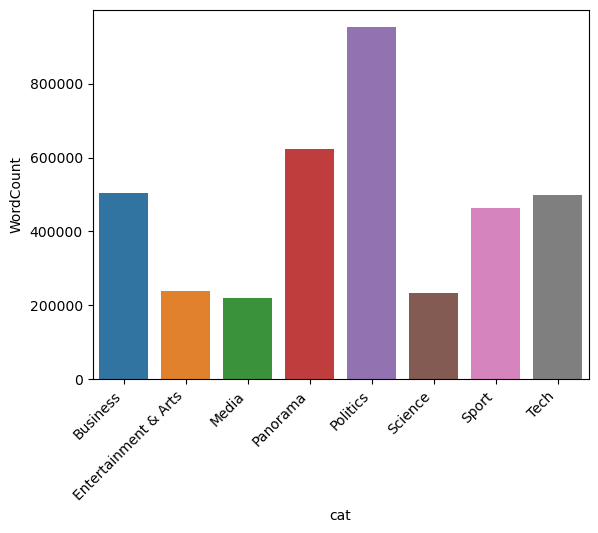

In [16]:
# Total word counts by category
counts=art_df.groupby('cat')['WordCount'].sum().to_frame().reset_index()

# Barplot
import seaborn as sns
import matplotlib.pyplot as plt

ax=sns.barplot(x='cat', y='WordCount', data=counts)

# Tilt the bar labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

print("Total word count:")

plt.show()

# Display word counts by category as df
#counts

Average word count:


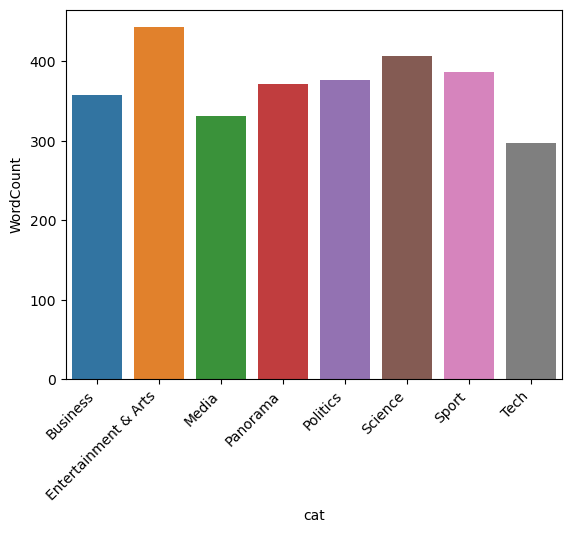

In [17]:
# Average word counts by category
avg_counts=art_df.groupby('cat')['WordCount'].mean().to_frame().reset_index()

# Barplot
import seaborn as sns
import matplotlib.pyplot as plt

ax2=sns.barplot(x='cat', y='WordCount', data=avg_counts)

# Tilt the bar labels
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

print("Average word count:")
plt.show()

In [18]:
# Description of counts by category
desc=art_df.groupby('cat')['WordCount'].describe()
desc

,count,mean,std,min,25%,50%,75%,max
cat,,,,,,,,
Business,1411.0,357.840539,229.936626,14.0,191.50,326.0,483.50,1914.0
Entertainment & Arts,539.0,442.816327,349.759814,8.0,219.00,352.0,563.00,2741.0
Media,668.0,331.175150,288.295863,12.0,154.75,247.0,438.75,2637.0
Panorama,1677.0,371.796661,255.432886,10.0,184.00,311.0,491.00,2832.0
Politics,2525.0,376.883168,272.809395,4.0,184.00,322.0,491.00,2553.0
Science,573.0,406.984293,264.641692,20.0,225.00,338.0,497.00,2238.0
Sport,1201.0,386.355537,257.235905,3.0,184.00,348.0,524.00,2411.0
Tech,1677.0,297.564699,272.331952,3.0,163.00,229.0,340.00,4800.0


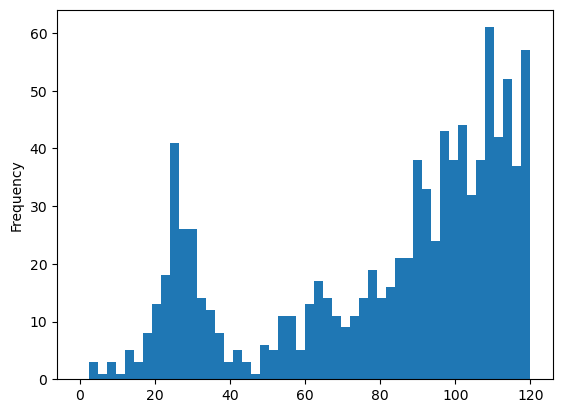

In [19]:
# Hist of WordCounts in range 0 to 120
import matplotlib.pyplot as plt
art_df['WordCount'].plot.hist(range=(0, 120), bins=50);

## 2.3 Data exclusion

In [20]:
# Remove articles with less than 47 words, as they are mostly captions
art_df=art_df.loc[art_df["WordCount"]>47,:]
art_df

,cat,text,WordCount
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001
3,Media,"Mitarbeiter überreichten Eigentümervertretern Petition gegen Personalabbau. Wien – Mehrere hundert APA-Mitarbeiter haben laut dem Betriebsrat eine Resolution unterschrieben, die am Mittwoch den Eigentümervertretern übergeben wurde. Inhalt ist ein deutlicher Protest gegen den geplanten Personalabbau (DER STANDARD berichtete) und für eine Gleichstellung der Mitarbeiter von APA-Tochterunternehmen bei automatischen Gehaltsanpassungen. Ich lehne erneute Personalkürzungen oder gar Kündigungen, wie...",250
4,Media,"Service: Jobwechsel in der Kommunikationsbranche im Überblick. Hier liefert derStandard.at/Etat Jobwechsel in der Kommunikationsbranche im Überblick. Grob sortiert nach Kalenderwochen, in denen die Infos einlangten. Quellen: Presse- und eigene Infos, andere Branchendienste wie Horizont.at und medianet.at. Wenn Sie Infos für uns haben, bitte ein Mail an etat@derstandard.at schicken. Woche 15 / 2017 Woche 14 / 2017 Woche 13 / 2017 Woche 12 / 2017 Woche 9 / 2017 Woche 8 / 2017 Woche 7 / 2017 Sp...",306
5,Media,"Was Sie über diese Woche wissen sollten - und was Sie gleich wieder vergessen können. Wien - Was hat sich diese Woche getan in der Medienwelt? Ist Ihnen da nichts entgangen? Besser noch einmal durchchecken – im Etat.at-Wochenquiz. Wir wünschen viel Spaß beim Mitmachen! Und für alle, die vorige Woche nicht so viel Zeit hatten, Medien-Nachrichten zu lesen: ein nützlicher Link.",61
...,...,...,...
10268,Science,"Die Fundstelle in Südengland ist Unesco-Weltkulturerbe, neolithische Ikone und das archäologische Monument schlechthin. Auch für Archäologen ist die Arbeit dort streng reglementiert. Als wir an einem Februartag um 5.30 Uhr mit unserem Bodenradar Mira 1 über einen Feldweg auf Stonehenge zufahren, bin ich leicht angespannt. Die Erlaubnis dafür, als erstes Team den Bereich innerhalb des Steinkreises mit motorisierten geophysikalischen Messgeräten zu untersuchen, haben wir erst am Tag davor von ...",1022
10269,Science,"Im Team arbeitet auch ein Inspektor der sudanesischen Antikenverwaltung. Gearbeitet wird sechs Tage die Woche, der Arbeitstag in Amara West beginnt um 5.50 Uhr. Woche drei im Sudan, und die Grabung kann nun wirklich beginnen. Auch das Team ist mittlerweile vollständig, es ist das gleiche wie im vergangenen Jahr: Michelle, die kanadische Anthropologin, die keine feste Anstellung hat und daher einen Großteil des Jahres auf Ausgrabungen in der Türkei, Zypern, Katar, Schottland und England verbr...",940
10270,Science,"Die zentrale Frage des Projekts: Siedelten Ägypter hierher, oder übernahmen Nubier Elemente der ägyptischen Kultur?. Woche fünf in Amara West war von mehreren außergewöhnlichen Ereignissen gekennzeichnet. Zum einen hat uns ein Magen-Darm-Virus erwischt, das abwechselnd einen Großteil des Teams kurzfristig außer Gefecht setzte. Das kommt im Durchschnitt einmal pro Kampagne vor, obwohl die hygienischen Verhältnisse im Sudan im Vergleich zu den meisten ande

In [21]:
# Info and description again
art_df.info()
art_df.describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10077 entries, 0 to 10272
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   cat        10077 non-null  object
 1   text       10077 non-null  object
 2   WordCount  10077 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 314.9+ KB


,WordCount
count,10077.000000
mean,370.248685
std,268.794275
min,48.000000
25%,186.000000
50%,304.000000
75%,482.000000
max,4800.000000


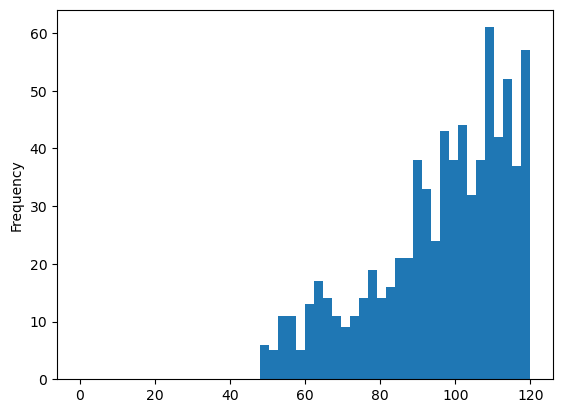

In [22]:
# Again, hist of WordCounts in range 0 to 120
import matplotlib.pyplot as plt
art_df['WordCount'].plot.hist(range=(0, 120), bins=50);

# 3. Text preprocessing

In [23]:
# Create copy of train_df to be used for text preprocessing
art_df_prep = art_df.copy()

## 3.1 Text cleaning

Removing HTML tags, special characters, punctuation, numbers, and extra whitespaces (but not replaceing umlauts and ß)

In [24]:
import re

# Function: remove HTML tags
def remove_html_tags(text):
    clean_text = re.sub('<.*?>', '', text)
    return clean_text

# Function: remove special characters, numbers, and punctuation
def remove_special_characters(text):
    clean_text = re.sub(r'[^a-zA-Z\sßüöä]', '', text)
    return clean_text

# Function: convert text to lowercase
def convert_to_lowercase(text):
    return text.lower()

# Function: remove extra whitespace
def remove_extra_whitespace(text):
    clean_text = re.sub(r'\s+', ' ', text)
    return clean_text.strip()

# Apply text cleaning steps to 'text' column
art_df_prep['text_cleaned'] = art_df_prep['text'].apply(lambda x: remove_html_tags(x))
art_df_prep['text_cleaned'] = art_df_prep['text_cleaned'].apply(lambda x: remove_special_characters(x))
art_df_prep['text_cleaned'] = art_df_prep['text_cleaned'].apply(lambda x: convert_to_lowercase(x))
art_df_prep['text_cleaned'] = art_df_prep['text_cleaned'].apply(lambda x: remove_extra_whitespace(x))

art_df_prep.head(2)


,cat,text,WordCount,text_cleaned
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138,die ardtochter degeto hat sich verpflichtet ab august einer quotenregelung zu folgen die für die gleichstellung von regisseurinnen sorgen soll in mindestens prozent der filme die die ardtochter degeto produziert oder mitfinanziert sollen ab mitte august frauen regie führen degetochefin christine strobl folgt mit dieser selbstverpflichtung der forderung von pro quote regie die vereinigung von regisseurinnen hatte im vergangenen jahr eine quotenregelung gefordert um den weiblichen filmschaffen...
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001,zum welttag der suizidprävention ist es zeit das alte dogma ber suizide schreibt man nicht zu verwerfen denn erst ausnahmen von dieser regel führen zu nachahmungen und wer über suizidalität dann schweigt wenn sie nicht sensationell ist stigmatisiert die betroffenen weiter halbwissen ist oft gefährlicher als nichtwissen werthereffekt ja ja schon mal gehört wird über einen suizid berichtet töten sich in der folge mehr menschen selbst so wie damals als goethes briefroman die leiden des jungen w...


## 3.2 Lemmatization

In [25]:
import spacy as sp

2023-06-05 14:42:39.814113: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [26]:
# Load the German language model
nlp = sp.load("de_core_news_sm")

In [27]:
# Function: lemmatize texts/articles (runs for 5 minutes)

def lemmatize_text(text):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

art_df_prep["text_lemmatized"] = art_df_prep["text_cleaned"].apply(lemmatize_text)

art_df_prep.head(3)

,cat,text,WordCount,text_cleaned,text_lemmatized
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138,die ardtochter degeto hat sich verpflichtet ab august einer quotenregelung zu folgen die für die gleichstellung von regisseurinnen sorgen soll in mindestens prozent der filme die die ardtochter degeto produziert oder mitfinanziert sollen ab mitte august frauen regie führen degetochefin christine strobl folgt mit dieser selbstverpflichtung der forderung von pro quote regie die vereinigung von regisseurinnen hatte im vergangenen jahr eine quotenregelung gefordert um den weiblichen filmschaffen...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der für der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie führen degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr Geh...
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001,zum welttag der suizidprävention ist es zeit das alte dogma ber suizide schreibt man nicht zu verwerfen denn erst ausnahmen von dieser regel führen zu nachahmungen und wer über suizidalität dann schweigt wenn sie nicht sensationell ist stigmatisiert die betroffenen weiter halbwissen ist oft gefährlicher als nichtwissen werthereffekt ja ja schon mal gehört wird über einen suizid berichtet töten sich in der folge mehr menschen selbst so wie damals als goethes briefroman die leiden des jungen w...,zu Welttag der Suizidprävention sein es Zeit der alt Dogma ber Suizide schreiben man nicht zu verwerfen denn erst Ausnahme von dieser Regel führen zu nachahmungen und wer über Suizidalität dann schweigen wenn sie nicht sensationell sein stigmatisieren der Betroffen weiter halbwissen sein oft gefährlich als Nichtwissen werthereffekt ja ja schon mal hören werden über ein Suizid berichten töten sich in der Folge mehr Mensch selbst so wie damals als goeth Briefroman der leid der jung Werther ers...
3,Media,"Mitarbeiter überreichten Eigentümervertretern Petition gegen Personalabbau. Wien – Mehrere hundert APA-Mitarbeiter haben laut dem Betriebsrat eine Resolution unterschrieben, die am Mittwoch den Eigentümervertretern übergeben wurde. Inhalt ist ein deutlicher Protest gegen den geplanten Personalabbau (DER STANDARD berichtete) und für eine Gleichstellung der Mitarbeiter von APA-Tochterunternehmen bei automatischen Gehaltsanpassungen. Ich lehne erneute Personalkürzungen oder gar Kündigungen, wie...",250,mitarbeiter überreichten eigentümervertretern petition gegen personalabbau wien mehrere hundert apamitarbeiter haben laut dem betriebsrat eine resolution unterschrieben die am mittwoch den eigentümervertretern übergeben wurde inhalt ist ein deutlicher protest gegen den geplanten personalabbau der standard berichtete und für eine gleichstellung der mitarbeiter von apatochterunternehmen bei automatischen 

**Stemming** is not applied. This is because lemmatization is the preferred method when preserving word meaning is relevant, and usually either lemmatization or stemming is applied, but not both.

## 3.3 Character replacement

In [28]:
# Define a dictionary for character replacement
character_replacements = {
    'ä': 'ae',
    'ö': 'oe',
    'ü': 'ue',
    'ß': 'ss'
}

# Function to replace characters in a string
def replace_characters(text):
    for old_char, new_char in character_replacements.items():
        text = text.replace(old_char, new_char)
    return text

# Apply character replacement to the 'Text' column
art_df_prep['text_replaced'] = art_df_prep['text_lemmatized'].apply(replace_characters)

art_df_prep.head(3)

,cat,text,WordCount,text_cleaned,text_lemmatized,text_replaced
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138,die ardtochter degeto hat sich verpflichtet ab august einer quotenregelung zu folgen die für die gleichstellung von regisseurinnen sorgen soll in mindestens prozent der filme die die ardtochter degeto produziert oder mitfinanziert sollen ab mitte august frauen regie führen degetochefin christine strobl folgt mit dieser selbstverpflichtung der forderung von pro quote regie die vereinigung von regisseurinnen hatte im vergangenen jahr eine quotenregelung gefordert um den weiblichen filmschaffen...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der für der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie führen degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr Geh...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der fuer der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie fuehren degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr G...
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001,zum welttag der suizidprävention ist es zeit das alte dogma ber suizide schreibt man nicht zu verwerfen denn erst ausnahmen von dieser regel führen zu nachahmungen und wer über suizidalität dann schweigt wenn sie nicht sensationell ist stigmatisiert die betroffenen weiter halbwissen ist oft gefährlicher als nichtwissen werthereffekt ja ja schon mal gehört wird über einen suizid berichtet töten sich in der folge mehr menschen selbst so wie damals als goethes briefroman die leiden des jungen w...,zu Welttag der Suizidprävention sein es Zeit der alt Dogma ber Suizide schreiben man nicht zu verwerfen denn erst Ausnahme von dieser Regel führen zu nachahmungen und wer über Suizidalität dann schweigen wenn sie nicht sensationell sein stigmatisieren der Betroffen weiter halbwissen sein oft gefährlich als Nichtwissen werthereffekt ja ja schon mal hören werden über ein Suizid berichten töten sich in der Folge mehr Mensch selbst so wie damals als goeth Briefroman der leid der jung Werther ers...,zu Welttag der Suizidpraevention sein es Zeit der alt Dogma ber Suizide schreiben man nicht zu verwerfen denn erst Ausnahme von dieser Regel fuehren zu nachahmungen und wer ueber Suizidalitaet dann schweigen wenn sie nicht sensationell sein stigmatisieren der Betroffen weiter halbwissen sein oft gefaehrlich als Nichtwissen werthereffekt ja ja schon mal hoeren werden ueber ein Suizid berichten toeten sic

## 3.4 Stopword removal

In [29]:
nlp = sp.load('de_core_news_sm')

In [54]:
# Function for stopword removal
def remove_stopwords(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

# Call function, adding a new col to df
art_df_prep['text_stopwords_removed'] = art_df_prep['text_replaced'].apply(remove_stopwords)

art_df_prep.head(3)

,cat,text,WordCount,text_cleaned,text_lemmatized,text_replaced,text_stopwords_removed
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138,die ardtochter degeto hat sich verpflichtet ab august einer quotenregelung zu folgen die für die gleichstellung von regisseurinnen sorgen soll in mindestens prozent der filme die die ardtochter degeto produziert oder mitfinanziert sollen ab mitte august frauen regie führen degetochefin christine strobl folgt mit dieser selbstverpflichtung der forderung von pro quote regie die vereinigung von regisseurinnen hatte im vergangenen jahr eine quotenregelung gefordert um den weiblichen filmschaffen...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der für der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie führen degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr Geh...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der fuer der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie fuehren degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr G...,Ardtochter Degeto verpflichten August quotenregelung folgen fuer Gleichstellung Regisseurinn sorgen mindestens Prozent Film Ardtochter Degeto produzieren mitfinanzieren Mitte August Frau Regie fuehren degetochefin Christine Strobl folgen Selbstverpflichtung Forderung pro quot Regie Vereinigung Regisseurinn vergangen Quotenregelung fordern weiblich Filmschaffend Gehoer oekonomisch Gleichstellung verschaffen pro quot Regie kritisieren waehrend Prozent regiestudierende weiblich Anteil Regisseur...
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001,zum welttag der suizidprävention ist es zeit das alte dogma ber suizide schreibt man nicht zu verwerfen denn erst ausnahmen von dieser regel führen zu nachahmungen und wer über suizidalität dann schweigt wenn sie nicht sensationell ist stigmatisiert die betroffenen weiter halbwissen ist oft gefährlicher als nichtwissen werthereffekt ja ja schon mal gehört wird über einen suizid berichtet töten sich in der folge mehr menschen selbst so wie damals als goethes briefroman die leiden des jungen w...,zu Welttag der Suizidprävention sein es Zeit der alt Dogma ber Suizide schreiben man nicht zu verwerfen denn erst Ausnahme von dieser Regel führen zu nachahmungen und wer über Suizidalität dann schweigen wenn sie nicht sensationell sein stigmatisieren der Betroffen weiter halbwissen sein oft gefährlich als Nichtwissen werthereffekt ja ja schon mal hören werden über ein Suizid beri

# 4. Train-test split

In [55]:
# Copy df before further processing
art_df_split = art_df_prep.copy()

## 4.1 Remove columns

In [56]:
# Remove col not required
art_df_split = art_df_split[['cat', 'text_stopwords_removed']]
art_df_split.head(2)

,cat,text_stopwords_removed
0,Media,Ardtochter Degeto verpflichten August quotenregelung folgen fuer Gleichstellung Regisseurinn sorgen mindestens Prozent Film Ardtochter Degeto produzieren mitfinanzieren Mitte August Frau Regie fuehren degetochefin Christine Strobl folgen Selbstverpflichtung Forderung pro quot Regie Vereinigung Regisseurinn vergangen Quotenregelung fordern weiblich Filmschaffend Gehoer oekonomisch Gleichstellung verschaffen pro quot Regie kritisieren waehrend Prozent regiestudierende weiblich Anteil Regisseur...
2,Media,Welttag Suizidpraevention alt Dogma ber Suizide schreiben verwerfen Ausnahme Regel fuehren nachahmungen ueber Suizidalitaet schweigen sensationell stigmatisieren Betroffen halbwissen gefaehrlich Nichtwissen werthereffekt mal hoeren ueber Suizid berichten toeten Folge Mensch goeth Briefroman leid jung Werther erscheinen ber Suizide berichten stimmen fast September Welttag Suizidpraevention Suizide verhinden muessen Journalist Verantwortung wahrnehmen bedeuten Fall alt Stehsatz ber Suizide sch...


## 4.2 Define X and y

In [57]:
# Define y
y = art_df_split.pop("cat")

# print(y.tolist())

In [58]:
# Define X
X = art_df_split
X.head(2)

,text_stopwords_removed
0,Ardtochter Degeto verpflichten August quotenregelung folgen fuer Gleichstellung Regisseurinn sorgen mindestens Prozent Film Ardtochter Degeto produzieren mitfinanzieren Mitte August Frau Regie fuehren degetochefin Christine Strobl folgen Selbstverpflichtung Forderung pro quot Regie Vereinigung Regisseurinn vergangen Quotenregelung fordern weiblich Filmschaffend Gehoer oekonomisch Gleichstellung verschaffen pro quot Regie kritisieren waehrend Prozent regiestudierende weiblich Anteil Regisseur...
2,Welttag Suizidpraevention alt Dogma ber Suizide schreiben verwerfen Ausnahme Regel fuehren nachahmungen ueber Suizidalitaet schweigen sensationell stigmatisieren Betroffen halbwissen gefaehrlich Nichtwissen werthereffekt mal hoeren ueber Suizid berichten toeten Folge Mensch goeth Briefroman leid jung Werther erscheinen ber Suizide berichten stimmen fast September Welttag Suizidpraevention Suizide verhinden muessen Journalist Verantwortung wahrnehmen bedeuten Fall alt Stehsatz ber Suizide sch...


## 4.3 Split

In [59]:
from sklearn.model_selection import train_test_split

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [60]:
len(X_train)

8061

In [61]:
len(y_train)

8061

# 5. Support Vector Machine

In [38]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.feature_selection import RFE
from nltk.tokenize import word_tokenize

## 5.1 Create pipeline and fit training data

In [62]:
# Define the pipeline
my_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()), # tokenizer=word_tokenize
    #('rfe', RFE(estimator=LinearSVC())), # Recursive feature selection
    ('classifier', LinearSVC())
])

# Fit the pipeline to the training data
my_pipeline.fit(X_train["text_stopwords_removed"], y_train)


Pipeline(steps=[('tfidf', TfidfVectorizer()), ('classifier', LinearSVC())])

In [63]:
# Vectorization and prediction for training data
my_pipeline.predict(X_train["text_stopwords_removed"])

array(['Media', 'Politics', 'Tech', ..., 'Science', 'Sport', 'Politics'],
      dtype=object)

## 5.2 Cross-validation

In [64]:
param_grid = {
    'tfidf__min_df': [1, 2, 3],
    'tfidf__max_df': [0.9],
    'classifier__C': [0.1, 1, 10],
    'classifier__loss': ['squared_hinge'],
    'classifier__penalty': ['l2'],
    'classifier__class_weight': [None]
    #'rfe__n_features_to_select': [1000, 5000, 10000]
    }

In [65]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(my_pipeline,
                      param_grid,
                      cv=5, # value for K in K-fold Cross Validation
                      scoring='accuracy', # performance metric to use, 
                     ) # verbose=1 we want informative outputs during the training process


In [66]:
# Fit "search" to training data (X and y)
search.fit(X_train["text_stopwords_removed"], y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('classifier', LinearSVC())]),
             param_grid={'classifier__C': [0.1, 1, 10],
                         'classifier__class_weight': [None],
                         'classifier__loss': ['squared_hinge'],
                         'classifier__penalty': ['l2'], 'tfidf__max_df': [0.9],
                         'tfidf__min_df': [1, 2, 3]},
             scoring='accuracy')

In [67]:
search.best_params_

{'classifier__C': 10,
 'classifier__class_weight': None,
 'classifier__loss': 'squared_hinge',
 'classifier__penalty': 'l2',
 'tfidf__max_df': 0.9,
 'tfidf__min_df': 1}

## 5.3 Model export

In [53]:
# Save trained model to file
import pickle

with open('de_class_svm_model.pkl', 'wb') as file:
    pickle.dump(search, file)

## 5.4 Metrics

In [46]:
from sklearn.metrics import accuracy_score

In [68]:
# Accuracy for training data
y_train_pred = search.predict(X_train["text_stopwords_removed"])
#y_train_pred = my_pipeline.predict(X_train["text_stopwords_removed"])

accuracy_score(y_train, y_train_pred)

0.9998759459124178

In [69]:
# Accuracy for test data
y_test_pred = search.predict(X_test["text_stopwords_removed"])
#y_test_pred = my_pipeline.predict(X_test["text_stopwords_removed"])

accuracy_score(y_test, y_test_pred)

0.8581349206349206

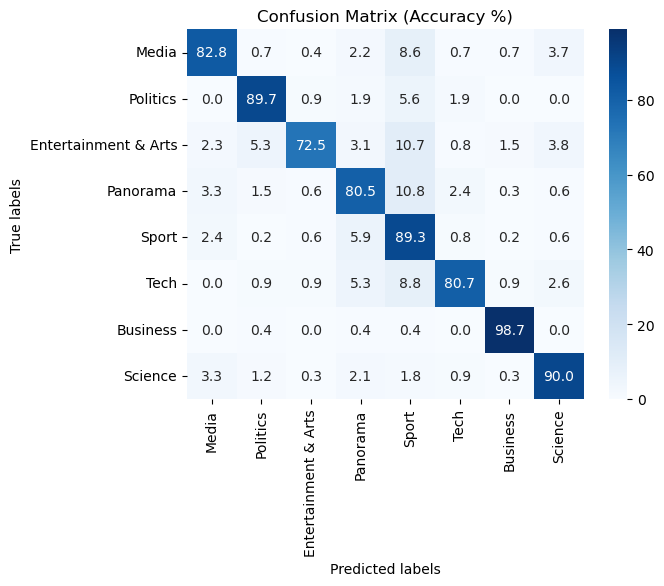

In [49]:
# Confusion matrix for accuracy

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Defining true labels and predicted labels for test data
true_labels = y_test
predicted_labels = y_test_pred

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create a list of class labels (optional, if you have class labels)
class_labels = art_df["cat"].unique().tolist()  # List of class labels in the order of the confusion matrix

# Create a heatmap using seaborn
sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.1f')

# Add labels, title, and axis ticks
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Accuracy %)')
plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=90)
plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)

# Create tick labels with class names
tick_labels = class_labels
#tick_labels = [f'{class_labels[i]} ({i})' for i in range(len(class_labels))]
plt.xticks(np.arange(len(class_labels)) + 0.5, tick_labels, rotation=90)
plt.yticks(np.arange(len(class_labels)) + 0.5, tick_labels, rotation=0)

# Display the plot
plt.show()


# 6. Input classification

In [50]:
# Open model from file
import pickle
with open('my_de_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [51]:
# Load spaCy model for German
nlp = sp.load('de_core_news_sm')

# Input text for instant classification
input_text = input("Enter text: ")

# Clean input text
def preprocess_text_clean(text):
    clean_text = re.sub('<.*?>', '', text) # Remove HTML tags
    clean_text = re.sub(r'[^a-zA-Z\sßüöä]', '', clean_text) # remove special characters, numbers, and punctuation
    clean_text = clean_text.lower() # lowercasing
    clean_text = re.sub(r'\s+', ' ', clean_text) # remove extra whitespace
    return clean_text.strip()

#Lemmatize input text
def lemmatize_text(text):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

# Replace characters of input text based on dict
character_replacements = {
    'ä': 'ae',
    'ö': 'oe',
    'ü': 'ue',
    'ß': 'ss'
}

def replace_characters(text):
    for old_char, new_char in character_replacements.items():
        text = text.replace(old_char, new_char)
    return text

def remove_stopwords(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

processed_text = preprocess_text_clean(input_text)
processed_text = lemmatize_text(processed_text)
processed_text = replace_characters(processed_text)
processed_text = remove_stopwords(processed_text)

prediction = loaded_model.predict([processed_text])
print(f'\nTopic: {prediction[0]}')

Enter text:  Das ist ein Text



Topic: Entertainment & Arts


In [52]:
# Perform prediction and get confidence scores (decision function values)
confidence_scores = loaded_model.decision_function([processed_text])[0]

# Get sorted list of categories
my_list=art_df["cat"].unique().tolist()
my_list = sorted(my_list)

# Create dict for storing category-score pairs (pos. scores only)
topic_dict = {}

# Assign classifications with positive confidence scores to dict
for category, score in zip(my_list, confidence_scores):
    #print(category, ": ", round(score, 3))
    if score > 0:
        topic_dict[category] = round(score, 3)
topic_dict_sorted = sorted(topic_dict.items(), key=lambda item: item[1], reverse=True)

# Print classifications with positive score or, if not available, best classification
if len(topic_dict) == 0:
    print(f'\nTopic: {prediction[0]}')
else:
    for entry in topic_dict_sorted:
        print (f'\nTopic: {entry[0]}')



Topic: Entertainment & Arts
